In [1]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
from collections import defaultdict
import seaborn as sns

In [2]:
def extract_durations(path):
    data = pd.read_csv(path, comment='#', header=None, sep='\t')
    durations = data.iloc[:,3] / 10        # convert to seconds
    return durations

def compute_durations(path, printing=True, prefix = "", last=0):
    durations = extract_durations(path)
    if last > 0:
        durations = durations[-last:]
    dur_mean, dur_se = compute_mean_s(durations)
    if printing:
        print(prefix, round(dur_mean, 2), "±" , round(dur_se, 2), "s")
    return dur_mean, dur_se

def compute_mean_s(data, se=True):
    data = np.array(data)
    mean = data.mean()
    s = data.std()
    if se:
        s /= math.sqrt(len(data))
    return mean, s


def plot_durations(path, window_size=25):
    durations = extract_durations(path)
    durations = durations.rolling(window_size).mean()
    plt.plot(durations)

def hist_durations(path):
    durations = extract_durations(path)
    plt.hist(durations)

## ORLA - Learning curve
Let's have a look at what the learning curve of ORLA looks like:

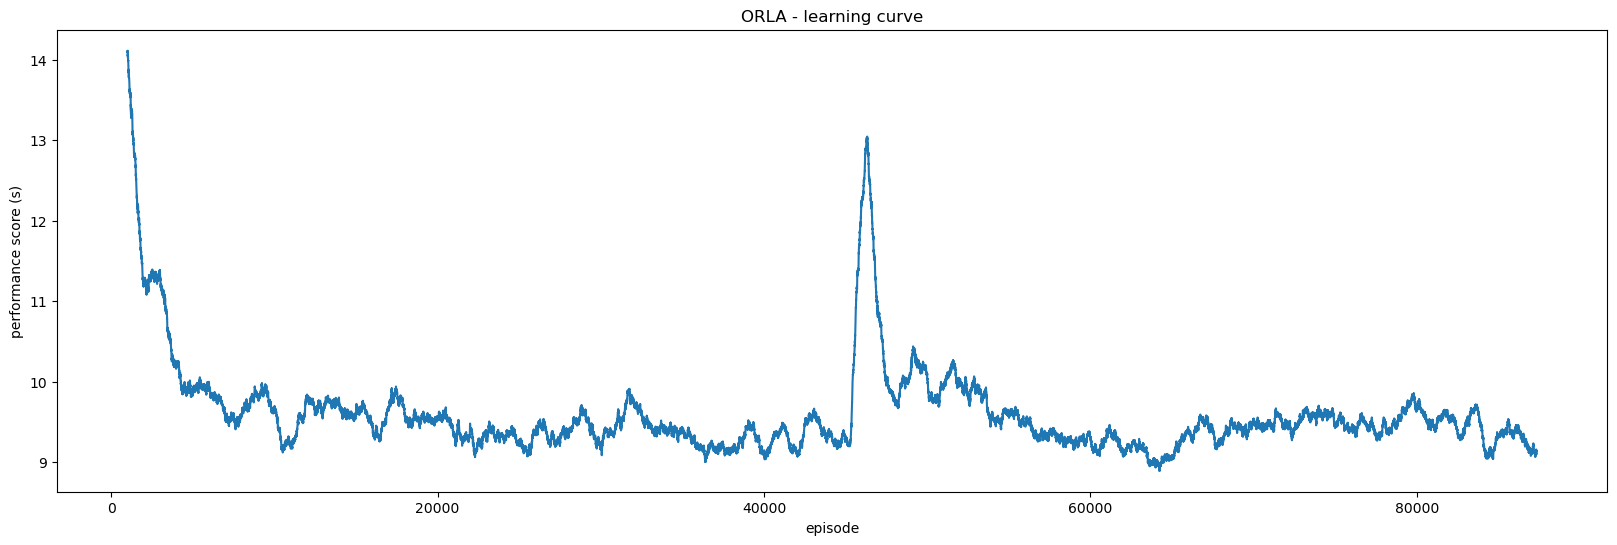

In [14]:
plt.rcParams["figure.figsize"] = (20,6)
plt.xlabel("episode")
plt.ylabel("performance score (s)")
plt.title("ORLA - learning curve")
plot_durations("./match_logs/40x40/orla_learning.kwy", window_size=1000)

### Performance metric
These are the perfromance metrics (i.e., the match durations in Takeaway) for each model for the logs obtained by playing with each model for 1000 episodes on a Takeaway field of sizes 30x30, 40x40 and 60x60.

In [3]:
# Uncomment the field size to analyze:
# field_size = "30x30"
field_size = "40x40"
# field_size = "60x60"

prefix = f"./match_logs/{field_size}"
print(field_size)

hand_path = f"{prefix}/handcrafted.kwy"
hand_mean, hand_se = compute_durations(hand_path, prefix="    Handcrafted:")

exp_path = f"{prefix}/expert.kwy"
exp_mean, exp_se = compute_durations(exp_path, prefix="    Expert:")

sarsa_path = f"{prefix}/sarsa.kwy"
sarsa_mean, sarsa_se = compute_durations(sarsa_path, prefix="    SARSA:")

ext_path = f"{prefix}/extracted.kwy"
ext_mean, ext_se = compute_durations(ext_path, prefix="    Extracted:")
# Fidelity score wrt sarsa (measured on 40x40):
# Agent 1 matchRatio: 99.0248
# Agent 2 matchRatio: 41.3613
# Agent 3 matchRatio: 96.9697

orla_loc_path = f"{prefix}/orla_local.kwy"
orla_loc_mean, orla_loc_se = compute_durations(orla_loc_path, prefix="    ORLA local:")
# Fidelity score wrt sarsa (measured on 40x40):
# Agent 1 matchRatio: 13.0118
# Agent 2 matchRatio: 20.3883
# Agent 3 matchRatio: 57.3828

orla_glob_path = f"{prefix}/orla_global.kwy"
orla_glob_mean, orla_glob_se = compute_durations(orla_glob_path, prefix="    ORLA global:")
# Fidelity score wrt sarsa (measured on 40x40):
# Agent 1 matchRatio: 16.0994
# Agent 2 matchRatio: 62.234
# Agent 3 matchRatio: 13.4942


40x40
    Handcrafted: 13.32 ± 0.29 s
    Expert: 9.68 ± 0.15 s
    SARSA: 9.14 ± 0.17 s
    Extracted: 12.16 ± 0.29 s
    ORLA local: 9.23 ± 0.15 s
    ORLA global: 9.44 ± 0.16 s


## Visual comparison of the distributions
This is just to have a better feel of what the above distributions look really like.

FIELD SIZE: 40x40


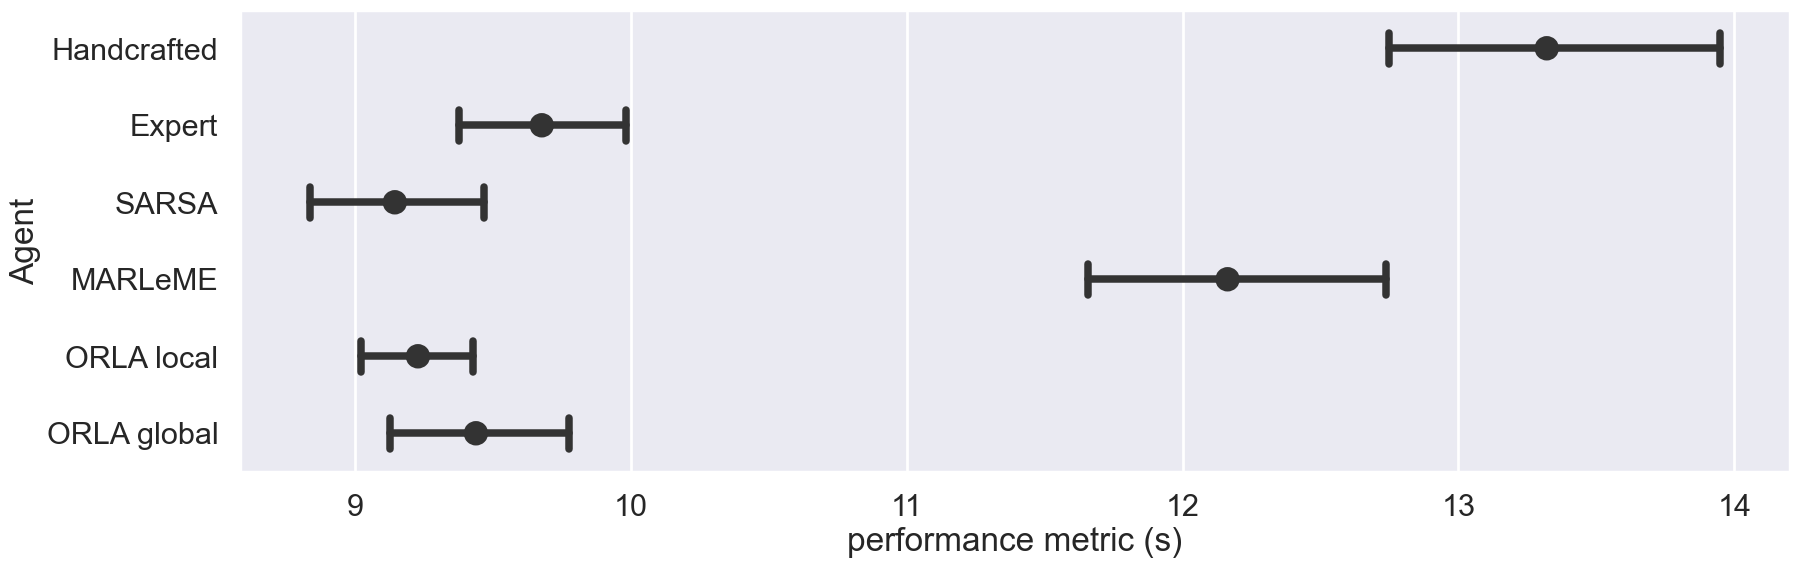

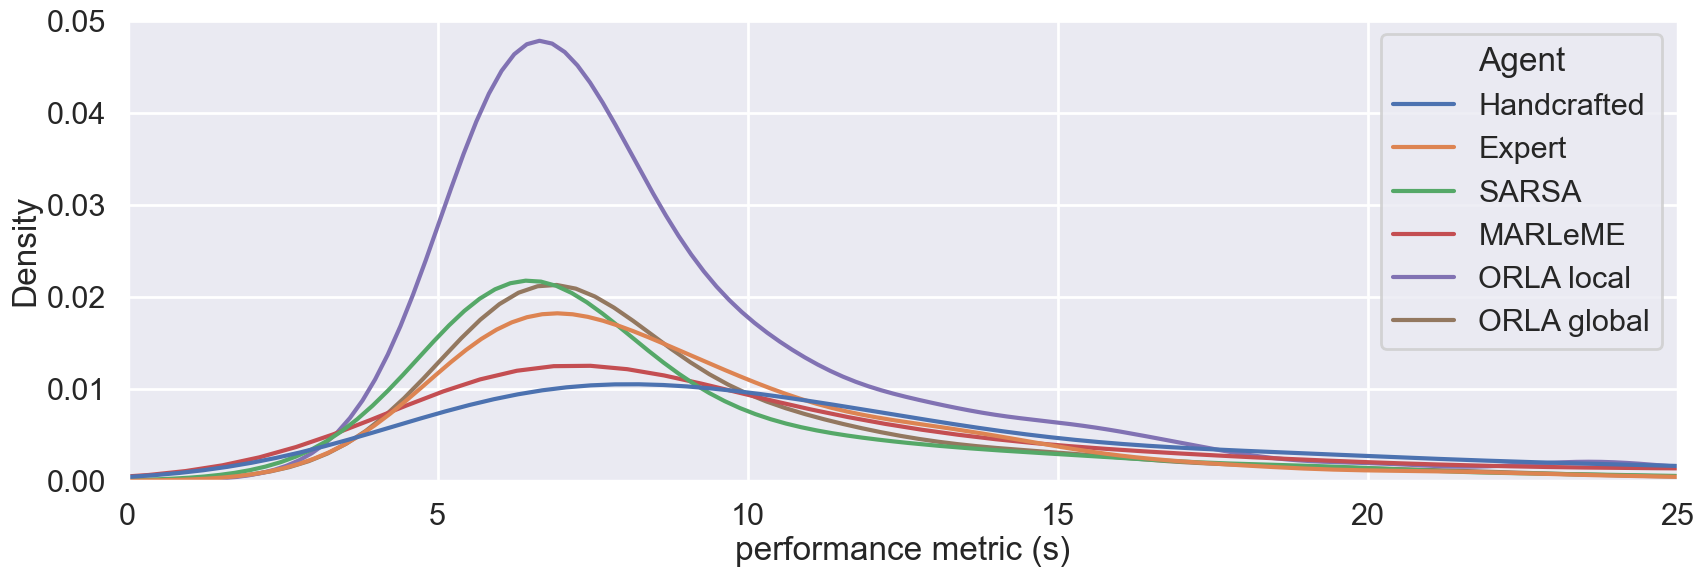

In [100]:
print(f"FIELD SIZE: {field_size}")


df_hand = pd.DataFrame(extract_durations(hand_path))
df_hand.columns = ['performance metric (s)']
df_hand['Agent'] = 'Handcrafted'

df_exp = pd.DataFrame(extract_durations(exp_path))
df_exp.columns = ['performance metric (s)']
df_exp['Agent'] = 'Expert'

df_orig = pd.DataFrame(extract_durations(sarsa_path))
df_orig.columns = ['performance metric (s)']
df_orig['Agent'] = 'SARSA'

df_ext = pd.DataFrame(extract_durations(ext_path))
df_ext.columns = ['performance metric (s)']
df_ext['Agent'] = 'MARLeME'

df_orla_loc = pd.DataFrame(extract_durations(orla_loc_path))
df_orla_loc.columns = ['performance metric (s)']
df_orla_loc['Agent'] = 'ORLA local'

df_orla_glob = pd.DataFrame(extract_durations(orla_glob_path))
df_orla_glob.columns = ['performance metric (s)']
df_orla_glob['Agent'] = 'ORLA global'

dfs = [df_hand, df_exp, df_orig, df_ext, df_orla_loc, df_orla_loc, df_orla_glob]

df = pd.concat(dfs, ignore_index=True )

sns.set_theme("poster")

sns.pointplot(
    data=df, x="performance metric (s)", y="Agent",
    errorbar=("se" ), capsize=.4, join=False, color=".2",
)

plt.show()

sns.kdeplot(data=df, x="performance metric (s)", hue="Agent")
plt.xlim(0,25)
plt.show()


## Ranking of arguments
This shows the ranking or arguments for each VAF-based model grouping arguments by taker.

In [59]:
t1_arguments = {
    0 : 'TackleBall1',
    1 : 'OpenKeeper1,2',
    2 : 'FarKeeper1,2',
    3 : 'MinAngle1,2',
    4 : 'MinDist1,2',
    5 : 'OpenKeeper1,3',
    6 : 'FarKeeper1,3',
    7 : 'MinAngle1,3',
    8 : 'MinDist1,3',
    9 : 'OpenKeeper1,4',
    10 : 'FarKeeper1,4',
    11 : 'MinAngle1,4',
    12 : 'MinDist1,4',
    39 : 'T1H1',
    40 : 'T1H2'}

t2_arguments = {
    13 : 'TackleBall2',
    14 : 'OpenKeeper2,2',
    15 : 'FarKeeper2,2',
    16 : 'MinAngle2,2',
    17 : 'MinDist2,2',
    18 : 'OpenKeeper2,3',
    19 : 'FarKeeper2,3',
    20 : 'MinAngle2,3',
    21 : 'MinDist2,3',
    22 : 'OpenKeeper2,4',
    23 : 'FarKeeper2,4',
    24 : 'MinAngle2,4',
    25 : 'MinDist2,4',
    41 : 'T2H1',
    42 : 'T2H2'}

t3_arguments = {
    26 : 'TackleBall3',
    27 : 'OpenKeeper3,2',
    28 : 'FarKeeper3,2',
    29 : 'MinAngle3,2',
    30 : 'MinDist3,2',
    31 : 'OpenKeeper3,3',
    32 : 'FarKeeper3,3',
    33 : 'MinAngle3,3',
    34 : 'MinDist3,3',
    35 : 'OpenKeeper3,4',
    36 : 'FarKeeper3,4',
    37 : 'MinAngle3,4',
    38 : 'MinDist3,4',
    43 : 'T3H1',
    44 : 'T3H2'}
all_arguments = t1_arguments | t2_arguments | t3_arguments

def get_ordering(path, arguments):
    ordering = pd.read_csv(path_ordering, header=None, sep=' ', names=(('argID', 'val')))
    ordering.sort_values('val', ascending=False, inplace=True)
    out = []
    last_val = -1
    for idx, row in ordering.iterrows():
        if row['argID'] in arguments.keys():
            if last_val == row['val']:
                out[-1].extend([arguments[row['argID']]])
            else:
                out.append([arguments[row['argID']]])
            last_val = row['val']
    return out

suffixes = ["extracted", "orla_local", "orla_global"]
for suffix in suffixes:
    path_ordering = f"./rankings/{suffix}.txt"
    print(suffix)
    o1 = get_ordering(path_ordering, t1_arguments)
    print("    T1: ", o1)
    o2 = get_ordering(path_ordering, t2_arguments)
    print("    T2: ", o2)
    o3 = get_ordering(path_ordering, t3_arguments)
    print("    T3: ", o3)


# print("Full ranking:")
# get_ordering(path_ordering, all_arguments)

extracted
    T1:  [['OpenKeeper1,4'], ['MinAngle1,4'], ['MinDist1,4'], ['FarKeeper1,4'], ['TackleBall1'], ['MinDist1,2'], ['MinAngle1,2'], ['OpenKeeper1,2'], ['FarKeeper1,2'], ['MinAngle1,3'], ['MinDist1,3'], ['OpenKeeper1,3'], ['FarKeeper1,3']]
    T2:  [['TackleBall2'], ['MinAngle2,3'], ['MinDist2,3'], ['FarKeeper2,3'], ['MinAngle2,4'], ['OpenKeeper2,3'], ['MinDist2,4'], ['MinAngle2,2'], ['MinDist2,2'], ['OpenKeeper2,2'], ['OpenKeeper2,4'], ['FarKeeper2,2'], ['FarKeeper2,4']]
    T3:  [['OpenKeeper3,3'], ['MinAngle3,3'], ['MinDist3,3'], ['FarKeeper3,3'], ['TackleBall3'], ['MinAngle3,4'], ['MinDist3,4'], ['OpenKeeper3,4'], ['FarKeeper3,4'], ['MinAngle3,2'], ['MinDist3,2'], ['OpenKeeper3,2'], ['FarKeeper3,2']]
orla_local
    T1:  [['TackleBall1'], ['MinAngle1,2'], ['MinDist1,2'], ['MinDist1,3'], ['OpenKeeper1,4'], ['OpenKeeper1,3'], ['FarKeeper1,4'], ['MinDist1,4'], ['FarKeeper1,2'], ['MinAngle1,3'], ['MinAngle1,4'], ['OpenKeeper1,2'], ['FarKeeper1,3']]
    T2:  [['TackleBall2'], ['Op

## Obtaining ORLA global
This is showcases how the ranking of ORLA global in the previous cell was obtained. Note that the orla_global.txt file is the already parsed ORLA global ranking (so you end up having the same non-strict ranking), but would normally be passing here the raw ORLA global ranking obtained during training (the one with the strict ranking we want to parse).

In [94]:
# Raw strict ORLA global ranking you want to pass (see markdown above).
path_ordering = "./rankings/orla_global.txt"

ordering = pd.read_csv(path_ordering, header=None, sep=' ', names=(('argID', 'val')))

values = defaultdict(lambda: [])

for idx, row in ordering.iterrows():
    keywords = ["TackleBall", "MinAngle", "MinDist", "FarKeeper", "OpenKeeper"]
    for keyword in keywords:
        if str(all_arguments[row['argID']]).startswith(keyword):
            values[keyword].append(row['val'])

global_values = dict()
for val in values:
    mean, sd = compute_mean_s(values[val], False)
    global_values[val] = int(mean)
    print("{}: {:d} ± {:d}".format(val, int(mean), round(sd)))


# Write the parsed non-strict ranking to a file
f = open("parsed_orla_global.txt", "w")
for arg in all_arguments:
    for key in global_values:
        if str(all_arguments[arg]).startswith(key):
            f.write("{} {}\n".format(arg, global_values[key]))

f.close()

TackleBall: 36 ± 0
OpenKeeper: 14 ± 0
FarKeeper: 12 ± 0
MinAngle: 25 ± 0
MinDist: 23 ± 0
